# BiLSTM Training mit Similarity-Filter

Dieses Notebook ermöglicht das Training eines BiLSTM-Klassifikators für Normales vs. Einfaches Deutsch. 
Der Datensatz kann basierend auf der semantischen Ähnlichkeit (Similarity) der Artikelpaare gefiltert werden.

In [ ]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
CSV_PATH = "results/information_loss_analysis_cleaned.csv"
LH_DATASET_PATH = "results/lebenshilfe_dataset_no_paragraphs.json"

BATCH_SIZE = 64
EMBEDDING_DIM = 128
EPOCHS = 20
HIDDEN_DIM = 128
LR = 1e-3
MAX_SEQ_LEN = 100
MAX_SIM = 0.98
MIN_SENT_LEN = 3
MIN_SIM = 0.8


In [1]:
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import spacy
nlp = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguration
# CSV_PATH = "results/information_loss_analysis_cleaned.csv"  # -> Zentral oben definiert
# MIN_SIM = 0.8  # Mindest-Ähnlichkeit  # -> Zentral oben definiert
# MAX_SIM = 0.98 # Maximal-Ähnlichkeit  # -> Zentral oben definiert

# MAX_SEQ_LEN = 100  # -> Zentral oben definiert
# MIN_SENT_LEN = 3  # -> Zentral oben definiert
# BATCH_SIZE = 64  # -> Zentral oben definiert
# EMBEDDING_DIM = 128  # -> Zentral oben definiert
# HIDDEN_DIM = 128  # -> Zentral oben definiert
# EPOCHS = 20  # -> Zentral oben definiert
# LR = 1e-3  # -> Zentral oben definiert
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Daten laden und filtern

In [2]:
def load_and_filter_data(csv_path, min_sim, max_sim):
    print(f"Lade Daten von {csv_path}...")
    df = pd.read_csv(csv_path)
    
    mask = (df["semantic_similarity_8192"] >= min_sim) & (df["semantic_similarity_8192"] <= max_sim)
    df_filtered = df[mask]
    
    print(f"Gefunden: {len(df_filtered)} Artikelpaare (von {len(df)} gesamt).")
    
    ls_sentences = []
    as_sentences = []
    
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
    
    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Verarbeite Texte"):
        ls_text = str(row["ls_text"])
        as_text = str(row["as_text"])
        
        # LS Sätze
        ls_doc = nlp(ls_text)
        for sent in ls_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                ls_sentences.append(tokens)
        
        # AS Sätze
        as_doc = nlp(as_text)
        for sent in as_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                as_sentences.append(tokens)
    
    print(f"Extrahierte Sätze: {len(ls_sentences)} LS, {len(as_sentences)} AS.")
    
    # Balancing
    min_len = min(len(ls_sentences), len(as_sentences))
    random.seed(42)
    random.shuffle(ls_sentences)
    random.shuffle(as_sentences)
    ls_sentences = ls_sentences[:min_len]
    as_sentences = as_sentences[:min_len]
    
    X = ls_sentences + as_sentences
    y = [1] * len(ls_sentences) + [0] * len(as_sentences)
    
    return X, y

X, y = load_and_filter_data(CSV_PATH, MIN_SIM, MAX_SIM)

Lade Daten von ../results/information_loss_analysis_cleaned.csv...
Gefunden: 1032 Artikelpaare (von 1476 gesamt).


Verarbeite Texte:   0%|          | 0/1032 [00:00<?, ?it/s]

Extrahierte Sätze: 20132 LS, 10692 AS.


## 2. Vorbereitung (Vocab & Dataset)

In [3]:
class Vocab:
    def __init__(self, sentences, max_size=20000, min_freq=2):
        counter = Counter()
        for sent in sentences:
            counter.update(sent)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
    def __len__(self): return len(self.itos)
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

class SentenceDataset(Dataset):
    def __init__(self, X, y, vocab, max_len):
        self.X, self.y, self.vocab, self.max_len = X, y, vocab, max_len
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        tokens = self.X[idx]
        encoded = self.vocab.encode(tokens)[:self.max_len]
        padded = encoded + [0] * (self.max_len - len(encoded))
        return torch.tensor(padded, dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

# Splits
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.11, random_state=42, stratify=y_train_val)

vocab = Vocab(X_train)
train_ds = SentenceDataset(X_train, y_train, vocab, MAX_SEQ_LEN)
val_ds = SentenceDataset(X_val, y_val, vocab, MAX_SEQ_LEN)
test_ds = SentenceDataset(X_test, y_test, vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Vocab size: {len(vocab)}")
print(f"Training samples: {len(train_ds)}")

Vocab size: 9239
Training samples: 17128


## 3. Modell & Training

In [4]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=1):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

model = BiLSTMClassifier(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

history = {'train_loss': [], 'val_loss': [], 'val_bacc': []}
best_val_acc = 0
patience = 5 
counter = 0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch_x).squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Validation
    model.eval()
    preds, targets = [], []
    val_epoch_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            out = model(bx).squeeze()
            val_epoch_loss += criterion(out, by).item()
            preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
            targets.extend(by.cpu().numpy())
    
    val_acc = balanced_accuracy_score(targets, preds)
    history['train_loss'].append(epoch_loss / len(train_loader))
    history['val_loss'].append(val_epoch_loss / len(val_loader))
    history['val_bacc'].append(val_acc)
    
    print(f"Epoch {epoch+1} - Loss: {history['train_loss'][-1]:.4f}, Val Loss: {history['val_loss'][-1]:.4f}, Val BAcc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"results/best_model_sim_{MIN_SIM}_{MAX_SIM}.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.4865, Val Loss: 0.3694, Val BAcc: 0.8351


Epoch 2:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.3445, Val Loss: 0.2998, Val BAcc: 0.8687


Epoch 3:   0%|          | 0/268 [00:00<?, ?it/s]

...

Epoch 16 - Loss: 0.0626, Val Loss: 0.2823, Val BAcc: 0.9244


Epoch 17:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 17 - Loss: 0.0566, Val Loss: 0.2855, Val BAcc: 0.9254


Epoch 18:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 18 - Loss: 0.0530, Val Loss: 0.3319, Val BAcc: 0.9221
Early stopping triggered.


## 4. Visualisierung der Ergebnisse

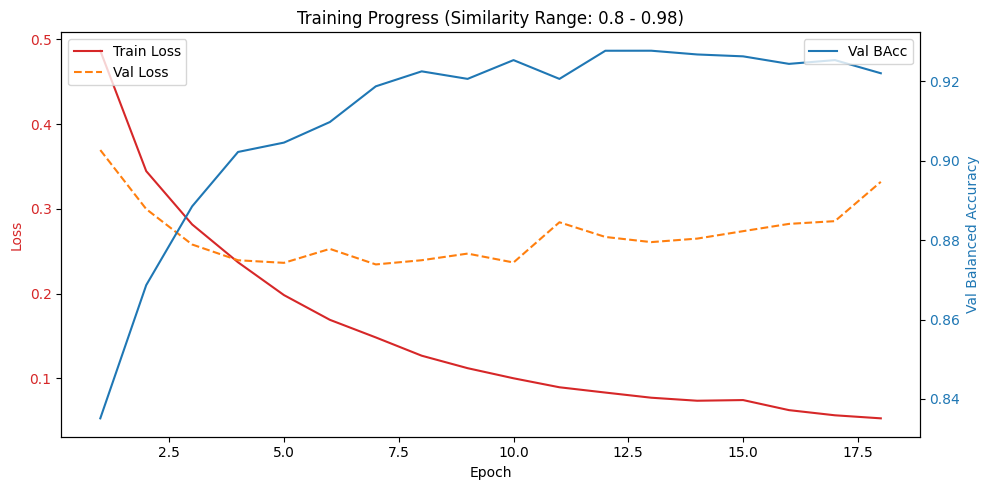

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(range(1, len(history['train_loss'])+1), history['train_loss'], color='tab:red', label='Train Loss')
ax1.plot(range(1, len(history['val_loss'])+1), history['val_loss'], color='tab:orange', label='Val Loss', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Val Balanced Accuracy', color='tab:blue')
ax2.plot(range(1, len(history['val_bacc'])+1), history['val_bacc'], color='tab:blue', label='Val BAcc')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper right')

plt.title(f'Training Progress (Similarity Range: {MIN_SIM} - {MAX_SIM})')
fig.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.93      0.92      1070
      Simple       0.92      0.92      0.92      1069

    accuracy                           0.92      2139
   macro avg       0.92      0.92      0.92      2139
weighted avg       0.92      0.92      0.92      2139



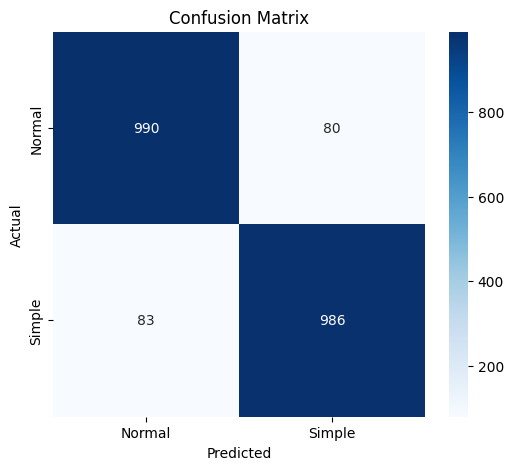

In [6]:
# Final evaluation on test-set
model.load_state_dict(torch.load(f"results/best_model_sim_{MIN_SIM}_{MAX_SIM}.pt"))
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        out = model(bx.to(DEVICE)).squeeze()
        test_preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
        test_targets.extend(by.numpy())

print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=["Normal", "Simple"]))

# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Simple"], yticklabels=["Normal", "Simple"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 5. Evaluation auf Artikelebene (Mehrheitsentscheid) für den gecrawlten Testdatensatz

Um die Leistung des Satzmodells direkt mit dem Artikelmodell vergleichen zu können, evaluieren wir hier das Satzmodell auf dem **gleichen Artikelebene-Testdatensatz** wie das Artikelmodell. 
Die Sätze jedes Artikels werden klassifiziert und die finale Artikelvorhersage wird per Mehrheitsentscheid (Majority Vote) ermittelt.

Evaluating Articles (Majority Vote):   0%|          | 0/309 [00:00<?, ?it/s]

 CRAWLED CORPUS ARTICLE-LEVEL EVALUATION (Majority Vote)
Article-Level Balanced Accuracy (Majority Vote): 99.68%

Classification Report (Article-Level):
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       154
      Simple       1.00      0.99      1.00       155

    accuracy                           1.00       309
   macro avg       1.00      1.00      1.00       309
weighted avg       1.00      1.00      1.00       309



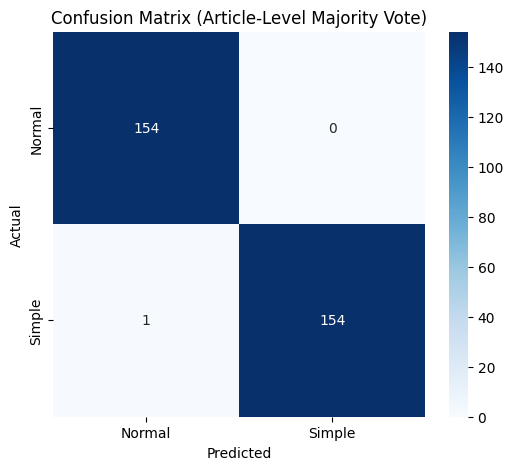

In [7]:
import spacy
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("results/information_loss_analysis_cleaned.csv")
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].copy()

X_raw = []
y_raw = []
nlp_blank = spacy.blank("de")

for _, row in df_filtered.iterrows():
    ls_text = str(row["ls_text"])
    as_text = str(row["as_text"])
    
    ls_tokens = [t.text.lower() for t in nlp_blank(ls_text) if not t.is_space]
    if len(ls_tokens) >= 10:
        X_raw.append(ls_text)
        y_raw.append(1)
        
    as_tokens = [t.text.lower() for t in nlp_blank(as_text) if not t.is_space]
    if len(as_tokens) >= 10:
        X_raw.append(as_text)
        y_raw.append(0)

_, X_test_raw, _, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw)

article_preds = []
model.eval()

for text in tqdm(X_test_raw, desc="Evaluating Articles (Majority Vote)"):
    doc = nlp(text)
    preds = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if not t.is_space]
        if len(tokens) >= MIN_SENT_LEN:
            encoded = vocab.encode(tokens)[:MAX_SEQ_LEN]
            padded = encoded + [0] * (MAX_SEQ_LEN - len(encoded))
            tensor = torch.tensor([padded], dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                output = model(tensor).squeeze()
                prob = torch.sigmoid(output).item()
                pred = 1 if prob > 0.5 else 0
            preds.append(pred)
    if not preds:
        preds = [0]
    
    # Mehrheitsentscheid
    article_preds.append(1 if np.mean(preds) > 0.5 else 0)

bacc_article_crawled = balanced_accuracy_score(y_test_raw, article_preds)

print("="*60)
print(" CRAWLED CORPUS ARTICLE-LEVEL EVALUATION (Majority Vote)")
print("="*60)
print(f"Article-Level Balanced Accuracy (Majority Vote): {bacc_article_crawled*100:.2f}%")
print("\nClassification Report (Article-Level):")
print(classification_report(y_test_raw, article_preds, target_names=["Normal", "Simple"]))

# Confusion Matrix
cm = confusion_matrix(y_test_raw, article_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Simple"], yticklabels=["Normal", "Simple"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Article-Level Majority Vote)')
plt.show()


## 6. Evaluation auf externem Lebenshilfe-Datensatz

Hier wird das trainierte Modell direkt auf dem externen, ungesehenen Lebenshilfe-Datensatz evaluiert. 
Da das Modell auf Satz-Ebene trainiert wurde, aggregieren wir die Vorhersagen über einen Mehrheitsentscheid (Majority Vote) auf Artikelebene.

In [8]:
import json
import spacy
nlp = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
import textstat
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# LH_DATASET_PATH = "results/lebenshilfe_dataset_no_paragraphs.json"  # -> Zentral oben definiert

if not os.path.exists(LH_DATASET_PATH):
    print(f"Lebenshilfe dataset not found at {LH_DATASET_PATH}")
else:
    with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
        lh_data = json.load(f)
        
    def predict_lh_sentence(tokens):
        encoded = vocab.encode(tokens)[:MAX_SEQ_LEN]
        padded = encoded + [0] * (MAX_SEQ_LEN - len(encoded))
        tensor = torch.tensor([padded], dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            output = model(tensor).squeeze()
            prob = torch.sigmoid(output).item()
            pred = 1 if prob > 0.5 else 0
        return pred, prob

    lh_results = []
    for item in tqdm(lh_data, desc="Evaluating Lebenshilfe"):
        ls_text = item.get("ls_text", "")
        as_text = item.get("as_text", "")
        if not ls_text or not as_text:
            continue
            
        ls_doc = nlp(ls_text)
        ls_preds, ls_probs = [], []
        for sent in ls_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                pred, prob = predict_lh_sentence(tokens)
                ls_preds.append(pred)
                ls_probs.append(prob)
                
        as_doc = nlp(as_text)
        as_preds, as_probs = [], []
        for sent in as_doc.sents:
            tokens = [t.text.lower() for t in sent if not t.is_space]
            if len(tokens) >= MIN_SENT_LEN:
                pred, prob = predict_lh_sentence(tokens)
                as_preds.append(pred)
                as_probs.append(prob)
                
        if not ls_preds: ls_preds, ls_probs = [0], [0.5]
        if not as_preds: as_preds, as_probs = [0], [0.5]
        
        ls_pred_maj = 1 if np.mean(ls_preds) > 0.5 else 0
        as_pred_maj = 1 if np.mean(as_preds) > 0.5 else 0
        
        lh_results.append({
            "LS_Pred": "Simple" if ls_pred_maj == 1 else "Normal",
            "AS_Pred": "Simple" if as_pred_maj == 1 else "Normal",
            "LS_Flesch": textstat.flesch_reading_ease(ls_text),
            "AS_Flesch": textstat.flesch_reading_ease(as_text),
            "LS_Wiener": textstat.wiener_sachtextformel(ls_text, 1),
            "AS_Wiener": textstat.wiener_sachtextformel(as_text, 1),
            "Correct": (ls_pred_maj == 1 and as_pred_maj == 0),
            "LS_Sents_Preds": ls_preds,
            "AS_Sents_Preds": as_preds
        })

    lh_all_ls_preds = []
    lh_all_as_preds = []
    for r in lh_results:
        lh_all_ls_preds.extend(r["LS_Sents_Preds"])
        lh_all_as_preds.extend(r["AS_Sents_Preds"])

    lh_y_true_sents = [1] * len(lh_all_ls_preds) + [0] * len(lh_all_as_preds)
    lh_y_pred_sents = lh_all_ls_preds + lh_all_as_preds
    
    lh_sent_acc = accuracy_score(lh_y_true_sents, lh_y_pred_sents)
    lh_sent_bacc = balanced_accuracy_score(lh_y_true_sents, lh_y_pred_sents)
    
    df_lh = pd.DataFrame(lh_results)
    lh_y_true_art = [1] * len(df_lh) + [0] * len(df_lh)
    lh_y_pred_art = list(df_lh["LS_Pred"].map({"Simple": 1, "Normal": 0})) + list(df_lh["AS_Pred"].map({"Simple": 1, "Normal": 0}))
    
    lh_art_acc = accuracy_score(lh_y_true_art, lh_y_pred_art)
    lh_art_bacc = balanced_accuracy_score(lh_y_true_art, lh_y_pred_art)
    
    print("\n" + "="*60)
    print(" LEBENSHILFE DATASET EVALUATION (Sentence-Level Model)")
    print("="*60)
    print(f"Sentence Accuracy: {lh_sent_acc*100:.2f}% (Balanced: {lh_sent_bacc*100:.2f}%)")
    print(f"Article Accuracy (Majority Vote): {lh_art_acc*100:.2f}% (Balanced: {lh_art_bacc*100:.2f}%)")
    print(f"Perfect Pair Match: {df_lh['Correct'].sum()} / {len(df_lh)} ({df_lh['Correct'].mean()*100:.1f}%) - (Both LS & AS correct)")
    print(f"Avg LS Flesch: {df_lh['LS_Flesch'].mean():.2f} (AS: {df_lh['AS_Flesch'].mean():.2f})")
    print(f"Avg LS Wiener: {df_lh['LS_Wiener'].mean():.2f} (AS: {df_lh['AS_Wiener'].mean():.2f})")

Evaluating Lebenshilfe:   0%|          | 0/49 [00:00<?, ?it/s]


 LEBENSHILFE DATASET EVALUATION (Sentence-Level Model)
Sentence Accuracy: 74.28% (Balanced: 78.76%)
Article Accuracy (Majority Vote): 96.94% (Balanced: 96.94%)
Perfect Pair Match: 46 / 49 (93.9%) - (Both LS & AS correct)
Avg LS Flesch: 66.40 (AS: 43.29)
Avg LS Wiener: 5.19 (AS: 9.07)
